# Predicting Loan Defaults with Machine Learning
### Logistic Regression · Decision Tree · LightGBM

---

## What problem are we solving?

When a bank approves a loan, it takes on **credit risk** — the risk that the borrower will not repay. Historically, banks used simple rule-based scorecards. Today, machine learning models are trained on thousands of historical loans to **predict whether a new applicant is likely to default**.

This is a **binary classification** problem:
- **0** → Borrower repays the loan ✅
- **1** → Borrower defaults on the loan ❌

## What you will learn

| Step | Topic |
|------|-------|
| 1 | Generate realistic synthetic loan data |
| 2 | Explore and visualise the data (EDA) |
| 3 | Preprocess features for modelling |
| 4 | Train three different classifiers |
| 5 | Evaluate and compare model performance |
| 6 | Make predictions on new borrowers |

## The three models we will compare

| Model | Think of it as... | Strength |
|---|---|---|
| **Logistic Regression** | A weighted scorecard | Simple, fast, interpretable |
| **Decision Tree** | A flowchart of yes/no questions | Easy to visualise and explain |
| **LightGBM** | An ensemble of many trees, each fixing the last | High accuracy on tabular data |

---
## Step 0: Install Dependencies

`lightgbm` is not part of the standard Python distribution, so we install it first.
The `!` prefix runs the command in your terminal/shell rather than as Python code.

> **Tip:** In Google Colab or a fresh environment, run this cell once. After that you can skip it.

In [1]:
# !pip install lightgbm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1: Import Libraries

We import everything up front so dependencies are visible at a glance.

| Library | Role |
|---|---|
| `numpy` | Numerical operations and random number generation |
| `pandas` | Tabular data (DataFrames) |
| `matplotlib` / `seaborn` | Plotting |
| `sklearn` | ML models, preprocessing, and evaluation metrics |
| `lightgbm` | Gradient boosting classifier |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

---
## Step 2: Generate Synthetic Loan Data

We don't have a real bank's proprietary data, so we **simulate** a realistic dataset.

### Features (inputs to the model)

| Feature | Description | Why it matters |
|---|---|---|
| `income` | Annual income (USD) | Higher income → more capacity to repay |
| `credit_score` | FICO score (300–850) | Standard measure of credit history |
| `debt_to_income` | Existing debt / income | High ratio = already stretched thin |
| `employment_duration` | Years at current job | Stability indicator |
| `housing_status` | Own / Rent / Mortgage | Asset ownership signal |
| `loan_amount` | Loan being applied for (USD) | Larger loans = higher exposure |

### How the target variable is created

We use a **logistic function** to assign default probabilities — the same mathematical form that Logistic Regression uses. Borrowers in the top 10% of default probability are labelled `is_default = 1`. This creates a realistic **~10% default rate**, matching real-world loan books.

> **`np.random.seed(42)`** ensures everyone gets the same dataset every time they run the cell — critical for reproducibility in teaching.

In [2]:
# np.random.seed(42)  # Fix randomness for reproducibility
# n_samples = 10000

# data = pd.DataFrame({
#     'income':               np.random.normal(50000, 15000, n_samples).astype('int'),
#     'credit_score':         np.random.randint(300, 850, n_samples),
#     'debt_to_income':       np.random.uniform(0.1, 0.6, n_samples),
#     'employment_duration':  np.round(np.random.exponential(5, n_samples), 2),
#     'housing_status':       np.random.choice(['Own', 'Rent', 'Mortgage'], n_samples),
#     'loan_amount':          np.round(np.random.normal(15000, 5000, n_samples), 2)
# })

# # Compute default probability using a logistic formula
# # Negative coefficients: high income & high credit_score reduce default risk
# # Positive coefficients: high debt_to_income & high loan_amount increase default risk
# logit = (-0.0001 * data['income']
#          - 0.01  * data['credit_score']
#          + 5.0   * data['debt_to_income']
#          + 0.0001 * data['loan_amount'])

# prob = 1 / (1 + np.exp(-logit))            # Sigmoid: maps logit → probability (0 to 1)
# data['is_default'] = np.where(prob > np.percentile(prob, 90), 1, 0)  # Top 10% → default

# # Save to disk and reload (simulates working with a real CSV file)
# data.to_csv("data_loan_defaulter.csv", index=False)

In [3]:
df = pd.read_csv("data_loan_defaulter.csv")
df.head()

# 0 → Borrower repays the loan ✅
# 1 → Borrower defaults on the loan ❌

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount,is_default
0,57450,330,0.373063,0.54,Mortgage,19110.21,0
1,47926,427,0.287471,1.54,Own,6676.08,0
2,59715,593,0.211456,8.48,Own,9511.77,0
3,72845,740,0.519618,3.51,Mortgage,15031.08,0
4,46487,687,0.337916,11.93,Mortgage,14856.23,0


---
## Step 3: Exploratory Data Analysis (EDA)

Before building any model, we must **understand the data**. EDA answers:
- Is the dataset balanced or imbalanced?
- Are features correlated with the target?
- Are there patterns we can spot visually?

### 3a. Class Imbalance

In real loan portfolios, defaults are rare — typically 5–15% of all loans. Our synthetic data mirrors this. This **class imbalance** is important: a naive model that always predicts "no default" would be 90% accurate but completely useless for risk management.

In [4]:
print("--- Default Counts ---")
print(df['is_default'].value_counts())

print("\n--- Default Rate (%) ---")
print(df['is_default'].value_counts(normalize=True).mul(100).round(1))

--- Default Counts ---
is_default
0    9000
1    1000
Name: count, dtype: int64

--- Default Rate (%) ---
is_default
0    90.0
1    10.0
Name: proportion, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_3536\2305522422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_default', data=df, palette='Set1', ax=axes[0])


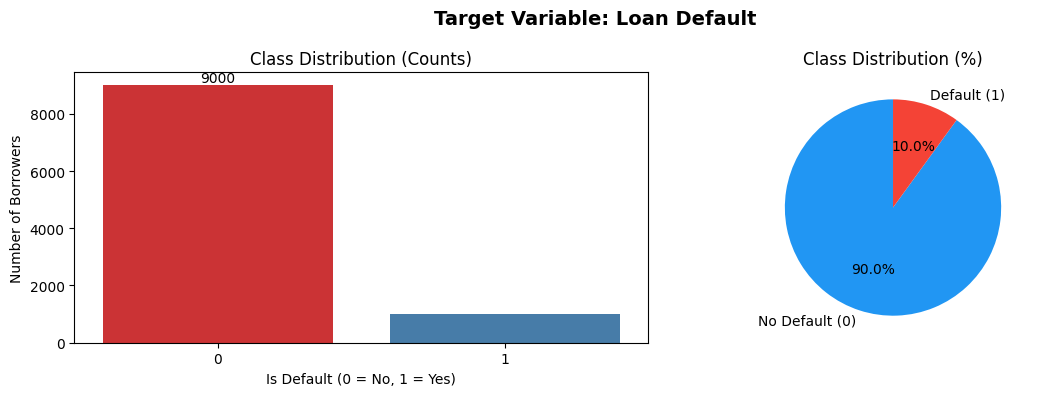

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Count bar chart
sns.countplot(x='is_default', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_xlabel('Is Default (0 = No, 1 = Yes)')
axes[0].set_ylabel('Number of Borrowers')
axes[0].bar_label(axes[0].containers[0])

# Right: Pie chart for percentage view
counts = df['is_default'].value_counts()
axes[1].pie(counts, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3b. Feature Distributions by Default Status

A great way to see which features are predictive is to **compare their distributions** between defaulters and non-defaulters. If the distributions look very different, the feature is a strong signal.

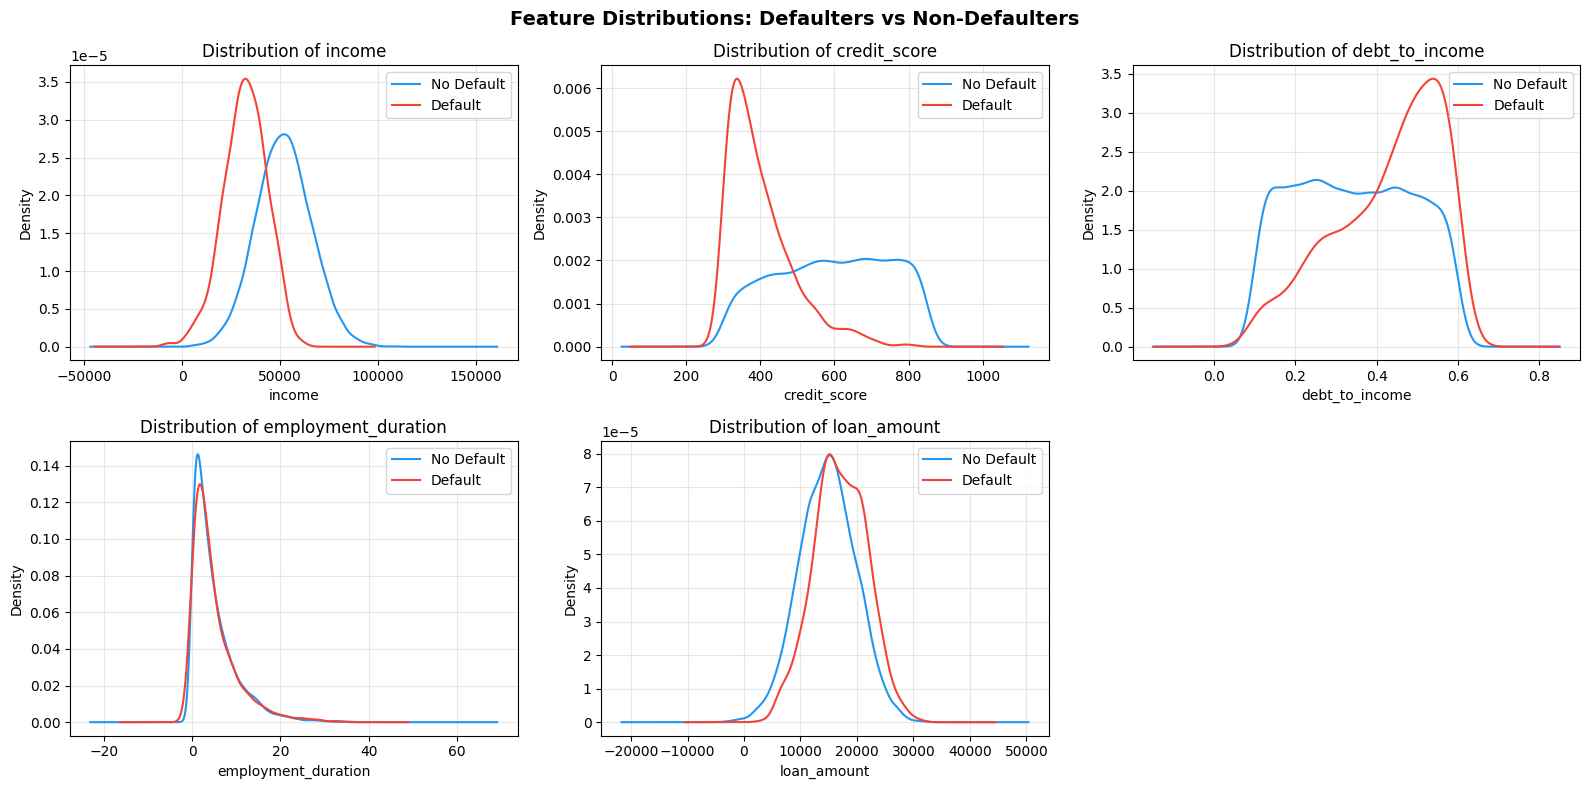

In [6]:
numeric_features = ['income', 'credit_score', 'debt_to_income', 'employment_duration', 'loan_amount']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # KDE plot: smoothed distribution curve, one per class
    df[df['is_default'] == 0][col].plot(kind='kde', ax=axes[i], label='No Default', color='#2196F3')
    df[df['is_default'] == 1][col].plot(kind='kde', ax=axes[i], label='Default', color='#F44336')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions: Defaulters vs Non-Defaulters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Correlation Heatmap

A **correlation matrix** shows how strongly pairs of numeric variables move together.
- Values close to **+1**: strong positive relationship
- Values close to **-1**: strong negative relationship  
- Values close to **0**: little to no linear relationship

For credit risk, the most important column to look at is `is_default`.

In [6]:
# 1) Temporarily encode housing_status for correlation analysis
df_corr = df.copy()
df_corr['housing_status'] = LabelEncoder().fit_transform(df_corr['housing_status']) # needs to be numerical
df_corr

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount,is_default
0,57450,330,0.373063,0.54,0,19110.21,0
1,47926,427,0.287471,1.54,1,6676.08,0
2,59715,593,0.211456,8.48,1,9511.77,0
3,72845,740,0.519618,3.51,0,15031.08,0
4,46487,687,0.337916,11.93,0,14856.23,0
...,...,...,...,...,...,...,...
9995,69516,794,0.296267,0.24,2,21710.79,0
9996,20024,718,0.522042,9.03,1,12671.28,0
9997,39420,505,0.371190,8.14,2,11826.44,0
9998,57436,617,0.335291,0.76,0,11776.00,0


Correlation matrix:
                        income  credit_score  debt_to_income  \
income               1.000000     -0.021965        0.009386   
credit_score        -0.021965      1.000000        0.017923   
debt_to_income       0.009386      0.017923        1.000000   
employment_duration -0.017517     -0.001886        0.002388   
housing_status      -0.006652      0.005123        0.021477   
loan_amount         -0.000152     -0.006843       -0.001251   
is_default          -0.392184     -0.366812        0.174081   

                     employment_duration  housing_status  loan_amount  \
income                         -0.017517       -0.006652    -0.000152   
credit_score                   -0.001886        0.005123    -0.006843   
debt_to_income                  0.002388        0.021477    -0.001251   
employment_duration             1.000000       -0.005669    -0.007457   
housing_status                 -0.005669        1.000000     0.008184   
loan_amount                    -0.00

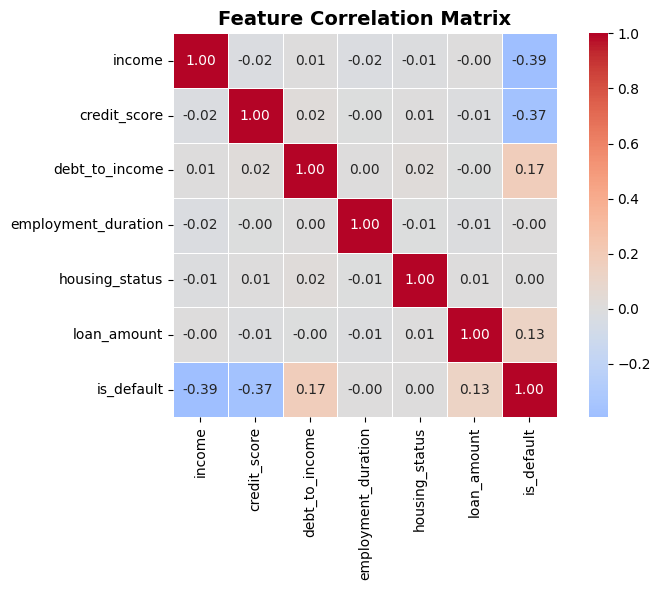

In [8]:
# 2) 
corr_matrix = df_corr.corr()
print("Correlation matrix:\n", corr_matrix)
print("-------------------")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Preprocessing

Raw data is rarely in the format ML models expect. We need to:

1. **Encode categorical variables** — models work with numbers, not text like `'Own'` or `'Rent'`
2. **Split data** into training and test sets
3. **Scale features** — required for Logistic Regression

### 4a. Label Encoding

`LabelEncoder` converts text categories to integers:

| Original | Encoded |
|---|---|
| Mortgage | 0 |
| Own | 1 |
| Rent | 2 |

> **Note:** Label encoding is fine for tree-based models. For linear models, `OneHotEncoding` is technically more correct, but we use it here for simplicity since it doesn't materially change results on this dataset.

In [9]:
le = LabelEncoder()
df['housing_status'] = le.fit_transform(df['housing_status'])

print("Encoding map:", dict(zip(le.classes_, le.transform(le.classes_))))
df.head()

Encoding map: {'Mortgage': np.int64(0), 'Own': np.int64(1), 'Rent': np.int64(2)}


,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount,is_default
0,57450,330,0.373063,0.54,0,19110.21,0
1,47926,427,0.287471,1.54,1,6676.08,0
2,59715,593,0.211456,8.48,1,9511.77,0
3,72845,740,0.519618,3.51,0,15031.08,0
4,46487,687,0.337916,11.93,0,14856.23,0


### 4b. Separate Features and Target

In ML convention:
- **X** (capital) = feature matrix — the inputs (everything except the answer)
- **y** (lowercase) = target vector — the answer we want to predict

In [10]:
X = df.drop(columns=['is_default'])  # All columns except the target
y = df['is_default']                 # Only the target column

print("X shape (rows, features):", X.shape)
print("y shape (rows,):         ", y.shape)

X shape (rows, features): (10000, 6)
y shape (rows,):          (10000,)


In [11]:
X

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount
0,57450,330,0.373063,0.54,0,19110.21
1,47926,427,0.287471,1.54,1,6676.08
2,59715,593,0.211456,8.48,1,9511.77
3,72845,740,0.519618,3.51,0,15031.08
4,46487,687,0.337916,11.93,0,14856.23
...,...,...,...,...,...,...
9995,69516,794,0.296267,0.24,2,21710.79
9996,20024,718,0.522042,9.03,1,12671.28
9997,39420,505,0.371190,8.14,2,11826.44
9998,57436,617,0.335291,0.76,0,11776.00


In [12]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: is_default, Length: 10000, dtype: int64

### 4c. Preview Two Specific Borrowers

We pick two borrowers — one non-defaulter, one defaulter — and track them through the rest of the notebook to see how each model scores them.

In [13]:
# Borrower at index 2  → actual label = 0 (did NOT default)
# Borrower at index 18 → actual label = 1 (DID default)
print("Borrower 2  | Features:", list(X.loc[2]),  "| Actual:", y[2])
print("Borrower 18 | Features:", list(X.loc[18]), "| Actual:", y[18])

Borrower 2  | Features: [59715.0, 593.0, 0.2114555894148319, 8.48, 1.0, 9511.77] | Actual: 0
Borrower 18 | Features: [36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86] | Actual: 1


### 4d. Split data into training / testing

We split the data so the model learns on one portion and is evaluated on another portion it has **never seen**.

**Why stratify?**
With `stratify=y`, the 90/10 default ratio is preserved in both the training and test sets. Without it, random chance could give the test set a very different ratio, making evaluation unreliable.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 80% train, 20% test
    stratify=y,      # Preserves the 90/10 class ratio in both splits
    random_state=42  # Reproducibility
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Default rate in train: {y_train.mean():.1%}")
print(f"Default rate in test:  {y_test.mean():.1%}")

Training set:  8,000 rows
Test set:      2,000 rows
Default rate in train: 10.0%
Default rate in test:  10.0%


In [17]:
# Verify that stratify works

# y_train.value_counts()
y_train.value_counts(normalize=True)*100


is_default
0    90.0
1    10.0
Name: proportion, dtype: float64

In [19]:
# Verify that stratify works

y_test.value_counts()
# y_test.value_counts(normalize=True)*100


is_default
0    1800
1     200
Name: count, dtype: int64

### 4e. Feature Scaling

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.

**Why is this necessary for Logistic Regression?**

Logistic Regression finds coefficients by gradient descent. If `income` ranges from 0–100,000 and `debt_to_income` ranges from 0.1–0.6, the algorithm treats them very differently. Scaling puts all features on the same footing, making convergence faster and coefficients comparable.

**Why fit only on training data?**
We use `.fit_transform()` on training data but only `.transform()` on test data. If we included test data in the fit, the scaler would "know" the test distribution — that's **data leakage**.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn mean/std from train, then scale
X_test_scaled  = scaler.transform(X_test)        # Apply the SAME learned mean/std to test

# Compare one row before and after scaling
print("Before scaling:", list(X_train.iloc[0].round(2)))
print("After scaling: ", list(X_train_scaled[0].round(4)))

Before scaling: [59608.0, 842.0, 0.48, 14.05, 2.0, 18920.78]
After scaling:  [np.float64(0.6302), np.float64(1.6729), np.float64(0.8758), np.float64(1.7911), np.float64(1.2304), np.float64(0.7784)]


In [22]:
# This temporarily changes the print format inside the block

print(X_train)
print("------------------")
with np.printoptions(suppress=True, precision=3):
    print(X_train_scaled)


      income  credit_score  debt_to_income  employment_duration  \
3556   59608           842        0.478707                14.05   
509    37535           782        0.386788                 0.15   
8016   39006           754        0.483771                 2.43   
287    58824           504        0.411161                 5.56   
5211   33822           764        0.165061                 7.55   
...      ...           ...             ...                  ...   
7708   39098           605        0.343485                 0.78   
6075   38437           352        0.346096                 6.14   
5091   39413           360        0.466417                 4.93   
9869   45327           319        0.364452                 9.37   
1699   52693           300        0.158076                 7.35   

      housing_status  loan_amount  
3556               2     18920.78  
509                1      4728.57  
8016               1     12095.91  
287                1     11594.57  
5211           

In [26]:
# Lets verify that mean=0 and std_dev=1 of column with index=0
print(np.mean(X_train_scaled[:, 0]))
print(np.std(X_train_scaled[:, 0]))

8.881784197001253e-18
1.0


---
## Model A: Logistic Regression

### How does it work?

Logistic Regression calculates a weighted sum of the features, then passes it through a **sigmoid function** to produce a probability between 0 and 1.

```
P(default) = sigmoid( w₁×income + w₂×credit_score + w₃×debt_to_income + ... )
```

If `P(default) > 0.5`, predict default. Otherwise, predict no default.

### Handling class imbalance: `class_weight='balanced'`

With 90% non-defaulters, the model is tempted to predict 0 for everyone. The `class_weight='balanced'` parameter automatically **increases the penalty** for misclassifying the minority class (defaulters), forcing the model to pay more attention to them.

In [27]:
# Train Logistic Regression on scaled data
# class_weight='balanced' adjusts penalties to account for the 90/10 class ratio
model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Predict class labels (0 or 1) and probabilities
y_pred_lr   = model_lr.predict(X_test_scaled)
y_proba_lr  = model_lr.predict_proba(X_test_scaled)[:, 1]  # Column 1 = P(default)

print("=== Logistic Regression ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      0.98      0.99      1800
     Default       0.86      1.00      0.93       200

    accuracy                           0.98      2000
   macro avg       0.93      0.99      0.96      2000
weighted avg       0.99      0.98      0.98      2000

ROC-AUC Score: 1.0000


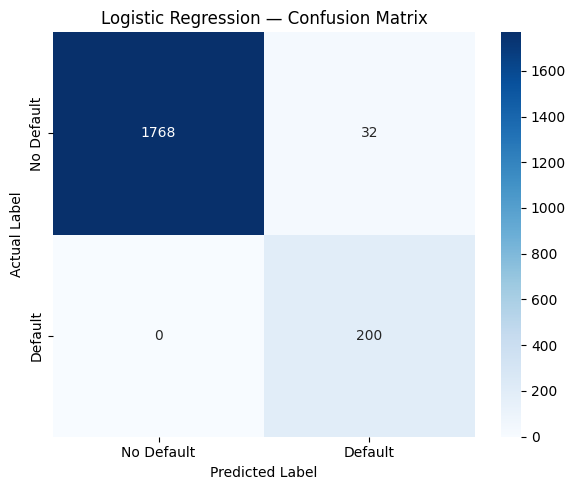

In [28]:
# Visualise the confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Understanding Evaluation Metrics

Before training any model, let's understand how we'll measure success.

### The Confusion Matrix

| | **Predicted: No Default** | **Predicted: Default** |
| :--- | :--- | :--- |
| **Actual: No Default** | ✅ **True Negative (TN):** Good loans approved | ❌ **False Positive (FP):** Good customer rejected *(lost revenue)* |
| **Actual: Default** | ❌ **False Negative (FN):** Risky loan approved *(financial loss)* | ✅ **True Positive (TP):** Risk correctly blocked |

### Key Metrics

| Metric | Formula | What it means in credit risk |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all predicted defaults, how many actually defaulted? |
| **Recall** | TP / (TP + FN) | Of all real defaults, how many did we catch? |
| **F1-Score** | 2 × Precision × Recall / (P + R) | Balance between precision and recall |
| **ROC-AUC** | Area under the ROC curve | Overall ability to separate classes (1.0 = perfect) |

### 💡 The Business Trade-off

> **Which mistake costs more?**
> - A **False Negative** (missed default) → Bank loses the loan amount
> - A **False Positive** (good customer rejected) → Bank loses a profitable customer
>
> In credit risk, **False Negatives are usually more costly**. This is why we optimise for **Recall** on the default class.

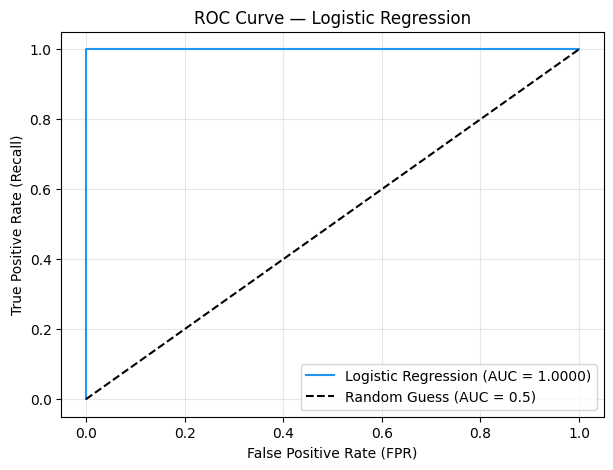

In [16]:
# ROC Curve: plots True Positive Rate vs False Positive Rate at every threshold
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='#2196F3')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# --- Score two specific borrowers ---
# Borrower 2: income=59715, credit_score=593, dti=0.211, emp_dur=8.48, housing=1, loan=9511
# Borrower 18: income=36379, credit_score=422, dti=0.486, emp_dur=16.55, housing=0, loan=13594

new_borrowers = [
    [59715, 593, 0.211456, 8.48,  1, 9511.77],   # Borrower 2  — actual: NO default
    [36379, 422, 0.485618, 16.55, 0, 13593.86],  # Borrower 18 — actual: DEFAULT
]

# Scale the new data using the SAME scaler fit on training data
new_borrowers_scaled = scaler.transform(new_borrowers)
# print("new_borrowers_scaled:\n", new_borrowers_scaled)

preds = model_lr.predict(new_borrowers_scaled)
probas = model_lr.predict_proba(new_borrowers_scaled)[:, 1]

print("Logistic Regression Predictions:")
for i, (pred, proba) in enumerate(zip(preds, probas)):
    label = 'DEFAULT' if pred == 1 else 'No Default'
    print(f"  Borrower {[2,18][i]}: {label} (P(default) = {proba:.2%})")

Logistic Regression Predictions:
  Borrower 2: No Default (P(default) = 0.00%)
  Borrower 18: DEFAULT (P(default) = 97.61%)


C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# OPTIONAL

---
## Model B: Decision Tree

### How does it work?

A Decision Tree asks a series of **yes/no questions** about the features, splitting the data at each node until it reaches a prediction. For example:

```
Is credit_score < 550?
├── Yes → Is debt_to_income > 0.45? → ...
└── No  → Is income < 30,000? → ...
```

### Key hyperparameter: `max_depth=5`

Without a depth limit, a tree can grow until it perfectly memorises the training data — but performs poorly on new data. This is called **overfitting**. Limiting depth forces the tree to find generalizable rules.

### Does it need feature scaling?

**No.** Decision trees split on thresholds (e.g., `income > 40,000`), so the absolute scale of features doesn't matter. We pass the **unscaled** `X_train` and `X_test` directly.

In [17]:
# max_depth=5 prevents overfitting — the tree can ask at most 5 questions
# class_weight='balanced' again addresses the 90/10 class imbalance
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)  # No scaling needed for tree-based models

y_pred_dt  = model_dt.predict(X_test)
y_proba_dt = model_dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Default', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")

=== Decision Tree ===

Classification Report:
              precision    recall  f1-score   support

  No Default       0.99      0.91      0.95      1800
     Default       0.52      0.93      0.67       200

    accuracy                           0.91      2000
   macro avg       0.76      0.92      0.81      2000
weighted avg       0.94      0.91      0.92      2000

ROC-AUC Score: 0.9551


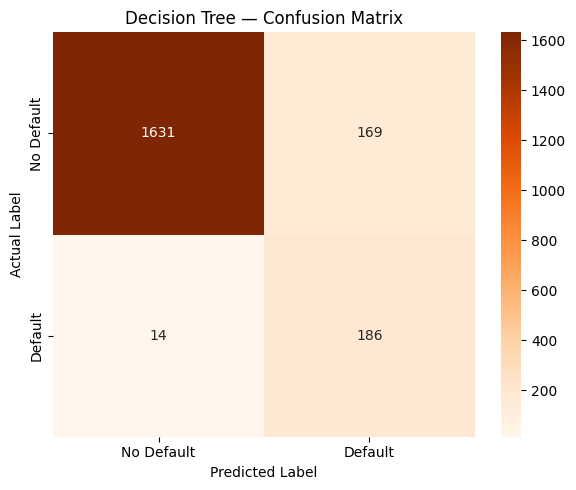

In [18]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

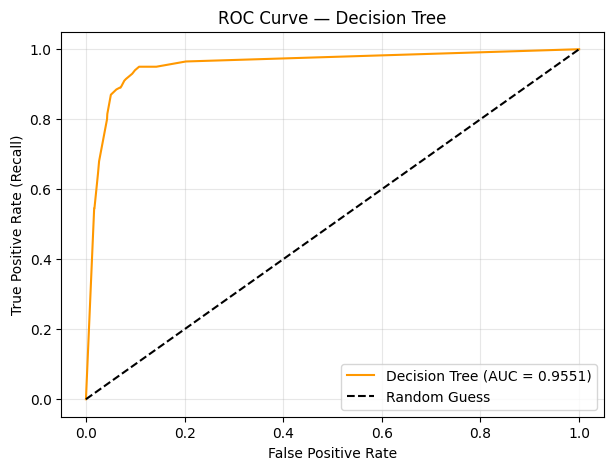

In [19]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', color='#FF9800')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Decision Tree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

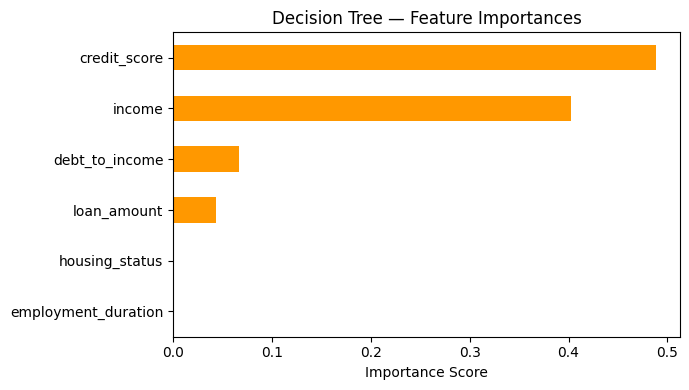

In [20]:
# Decision Tree feature importance — which features does it rely on most?
feat_imp = pd.Series(model_dt.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='barh', color='#FF9800')
plt.title('Decision Tree — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
# Test the same two borrowers — Decision Tree uses unscaled data
preds_dt = model_dt.predict(new_borrowers)
probas_dt = model_dt.predict_proba(new_borrowers)[:, 1]

print("Decision Tree Predictions:")
for i, (pred, proba) in enumerate(zip(preds_dt, probas_dt)):
    label = 'DEFAULT' if pred == 1 else 'No Default'
    print(f"  Borrower {[2,18][i]}: {label} (P(default) = {proba:.2%})")

Decision Tree Predictions:
  Borrower 2: No Default (P(default) = 0.00%)
  Borrower 18: DEFAULT (P(default) = 97.46%)


C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


---
## Model C: LightGBM (Gradient Boosting)

### How does it work?

LightGBM builds an **ensemble of decision trees sequentially**. Each new tree focuses on correcting the errors made by all previous trees. This is called **gradient boosting**.

Think of it as a team of analysts:
1. Analyst 1 makes predictions
2. Analyst 2 focuses only on the cases Analyst 1 got wrong
3. Analyst 3 focuses on what Analysts 1 and 2 both got wrong
4. … and so on for `n_estimators` rounds

### Handling class imbalance: `scale_pos_weight`

Instead of `class_weight='balanced'`, LightGBM uses `scale_pos_weight` — the ratio of negatives to positives. This tells the model: *"errors on the minority class (defaults) should be penalised this many times more."*

### Key hyperparameters

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | 200 | Number of trees to build |
| `learning_rate` | 0.05 | How much each tree corrects the previous (smaller = more careful) |
| `objective` | binary | Tells LightGBM this is a classification task |

In [22]:
# Calculate the class imbalance ratio: (# non-defaults) / (# defaults)
# e.g., if 9000 non-defaults and 1000 defaults → ratio = 9
ratio = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Class imbalance ratio (non-default : default) = {ratio:.1f}")

model_lgb = lgb.LGBMClassifier(
    objective='binary',          # Binary classification
    metric='auc',                # Optimise for AUC during training
    scale_pos_weight=ratio,      # Penalise missed defaults ratio× more
    learning_rate=0.05,          # Small steps = more robust
    n_estimators=200,            # Build 200 trees
    random_state=42
)

model_lgb.fit(X_train, y_train)  # Tree models do not require scaling

y_pred_lgb  = model_lgb.predict(X_test)
y_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]

print("\n=== LightGBM ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb, target_names=['No Default', 'Default']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lgb):.4f}")

Class imbalance ratio (non-default : default) = 9.0
[LightGBM] [Info] Number of positive: 800, number of negative: 7200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100000 -> initscore=-2.197225
[LightGBM] [Info] Start training from score -2.197225

=== LightGBM ===

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      0.99      0.99      1800
     Default       0.89      0.96      0.93       200

    accuracy                           0.98      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       0.99      0.98      0.99      2000

ROC-AUC Score: 0.9986


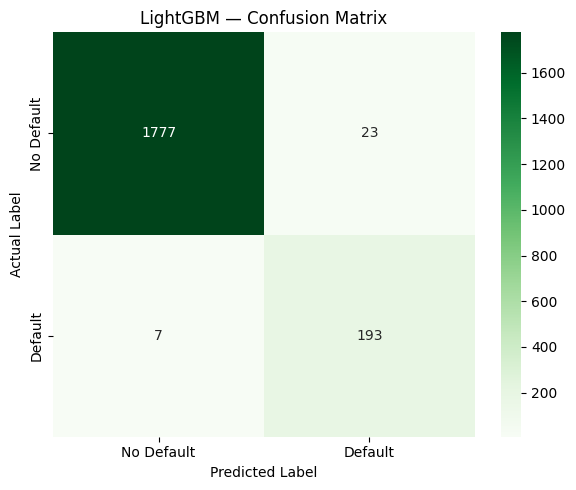

In [23]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('LightGBM — Confusion Matrix')
plt.tight_layout()
plt.show()

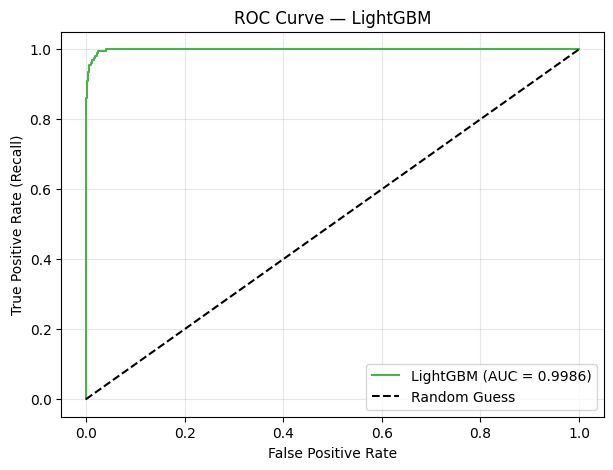

In [24]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)
auc_lgb = auc(fpr_lgb, tpr_lgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', color='#4CAF50')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — LightGBM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

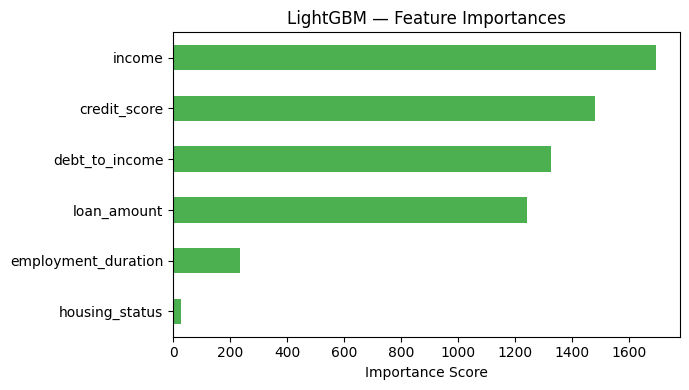

In [25]:
# LightGBM feature importance
feat_imp_lgb = pd.Series(model_lgb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp_lgb.plot(kind='barh', color='#4CAF50')
plt.title('LightGBM — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [26]:
preds_lgb = model_lgb.predict(new_borrowers)
probas_lgb = model_lgb.predict_proba(new_borrowers)[:, 1]

print("LightGBM Predictions:")
for i, (pred, proba) in enumerate(zip(preds_lgb, probas_lgb)):
    label = 'DEFAULT' if pred == 1 else 'No Default'
    print(f"  Borrower {[2,18][i]}: {label} (P(default) = {proba:.2%})")

LightGBM Predictions:
  Borrower 2: No Default (P(default) = 0.00%)
  Borrower 18: DEFAULT (P(default) = 99.66%)


---
## Model Comparison

Now let's bring all three models together and compare them on the same charts.

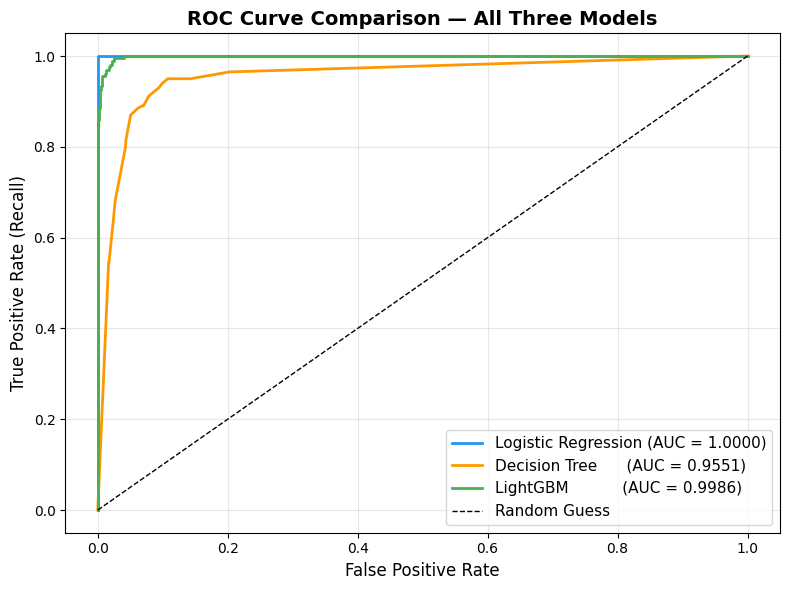

In [27]:
# --- Combined ROC Curve ---
# A single chart makes it easy to rank models by AUC
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.4f})',  color='#2196F3', lw=2)
plt.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree      (AUC = {auc_dt:.4f})',  color='#FF9800', lw=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM           (AUC = {auc_lgb:.4f})', color='#4CAF50', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', lw=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — All Three Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# --- Summary Metrics Table ---
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'LightGBM'],
    'Accuracy':           [accuracy_score(y_test, y_pred_lr),
                           accuracy_score(y_test, y_pred_dt),
                           accuracy_score(y_test, y_pred_lgb)],
    'Precision (Default)': [precision_score(y_test, y_pred_lr),
                            precision_score(y_test, y_pred_dt),
                            precision_score(y_test, y_pred_lgb)],
    'Recall (Default)':   [recall_score(y_test, y_pred_lr),
                           recall_score(y_test, y_pred_dt),
                           recall_score(y_test, y_pred_lgb)],
    'F1 (Default)':       [f1_score(y_test, y_pred_lr),
                           f1_score(y_test, y_pred_dt),
                           f1_score(y_test, y_pred_lgb)],
    'ROC-AUC':            [auc_lr, auc_dt, auc_lgb]
})

results = results.set_index('Model').round(4)
results.style.highlight_max(axis=0, color='#c8e6c9')  # Highlight best score per column

,Accuracy,Precision (Default),Recall (Default),F1 (Default),ROC-AUC
Model,,,,,
Logistic Regression,0.984000,0.862100,1.000000,0.925900,1.000000
Decision Tree,0.908500,0.523900,0.930000,0.670300,0.955100
LightGBM,0.985000,0.893500,0.965000,0.927900,0.998600


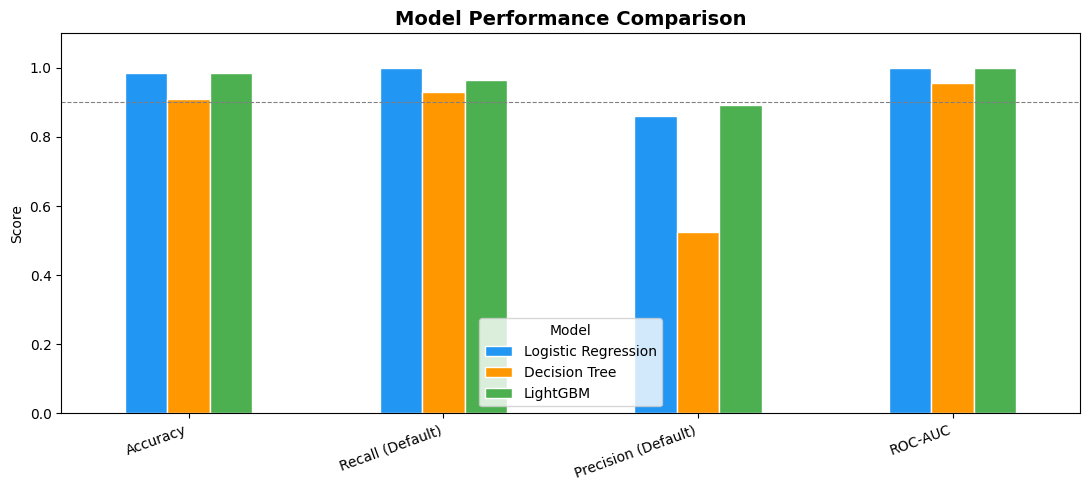

In [29]:
# --- Bar chart of key metrics ---
metrics_to_plot = ['Accuracy', 'Recall (Default)', 'Precision (Default)', 'ROC-AUC']
plot_data = results[metrics_to_plot]

plot_data.T.plot(kind='bar', figsize=(11, 5), color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend(title='Model')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, label='0.90 reference')
plt.tight_layout()
plt.show()

---
## Final Interpretation

### What do the results tell us?

All three models perform strongly because this is **synthetic data** with a clear underlying signal — we literally designed the default labels using a logistic formula. In real-world data, these scores would be lower.

### Model-by-model takeaways

#### Logistic Regression
- **Recall = very high** → Catches nearly all defaults
- **ROC-AUC ≈ 1.0** → Near-perfect separation
- This is expected — the data was generated with a logistic formula, so a logistic model fits it almost perfectly
- **Use when:** Interpretability matters (regulators, auditors). Each coefficient tells you exactly how much each variable influences the default probability.

#### Decision Tree
- **Lower precision** → More false alarms (good customers rejected)
- **Lower AUC** → Weaker overall discrimination
- A single tree tends to overfit noisy patterns and struggles to match ensemble methods
- **Use when:** You need to explain the model visually to a non-technical audience (e.g., "if credit score < 550 AND debt-to-income > 0.45, decline the application")

#### LightGBM
- **Highest precision** → Fewer false alarms while maintaining high recall
- **AUC ≈ 0.999** → Almost as good as Logistic Regression on this dataset
- Usually the top performer on messy, real-world tabular data
- **Use when:** Raw predictive performance is the priority and you have sufficient data

### Which model should a bank choose?

| Priority | Recommended Model | Reason |
|---|---|---|
| Zero tolerance for missed defaults | Logistic Regression | Highest recall |
| Best overall accuracy + precision | LightGBM | Best F1 score |
| Model explainability / regulation | Logistic Regression | Interpretable coefficients |
| Teaching / visualising the logic | Decision Tree | Human-readable rules |

### ⚠️ A note on suspiciously high scores

A ROC-AUC of 1.0 should always raise questions in practice. Before deploying any model, verify:
1. **No data leakage** — Is any feature derived from the target variable?
2. **Proper split order** — Did preprocessing (scaling, encoding) happen after the train/test split?
3. **No duplicate rows** shared across train and test sets
4. **Features are available at prediction time** — Can you really know `credit_score` before approving a loan?

---
## Summary

| Concept | What you learned |
|---|---|
| Synthetic data generation | How to create realistic loan data with controlled default rates |
| Class imbalance | Why a 90/10 split requires special handling (`class_weight`, `scale_pos_weight`) |
| Label encoding | Converting categorical variables for ML models |
| Train/test split with stratification | Preventing biased evaluation on imbalanced datasets |
| Feature scaling | Why Logistic Regression needs it; why trees do not |
| Confusion matrix | How to read TP, TN, FP, FN in a business context |
| Precision vs Recall trade-off | Why credit risk prioritises Recall over Precision |
| ROC-AUC | Threshold-independent measure of model discrimination |
| Feature importance | Which variables drive predictions in tree-based models |
| Model selection | Choosing the right model based on business priorities |

### Suggested next steps
- Try changing `max_depth` in the Decision Tree and observe how it affects overfitting
- Try `n_estimators=50` vs `n_estimators=500` in LightGBM and compare AUC scores
- Explore `threshold tuning` — changing the 0.5 cutoff to improve Recall at the cost of Precision
- Look into **SHAP values** for explaining individual LightGBM predictions